New Order
- Train, val, test splitting sections 1-3
  - Hyperparameter tuning
    - https://www.youtube.com/watch?v=HgkiKRYc-3A
- Dataloader & Dataset section 4


## Setup

### Import Libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import xarray as xr
import owncloud
from pathlib import Path
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

### Utility Functions

In [237]:
def train(model: nn.Module, features_train: torch.Tensor, labels_train: torch.Tensor, nepochs:int = 20, learning_rate: float = 0.001) -> None:

    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

    loss_function = nn.CrossEntropyLoss()

    losses = []
    accuracies = []
    for epoch in tqdm(range(nepochs)):


        optimizer.zero_grad()

        output = model.forward(features_train)

        loss = loss_function(output, labels_train)
        losses.append(loss.item())

        loss.backward()

        optimizer.step()

        accuracy = (labels_train == torch.argmax(output, dim=1)).sum()/len(labels_train)
        accuracies.append(accuracy)

def calculate_accuracy(model: nn.Module, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor: 

    output = model(features)

    accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)

    return (accuracy*100).item()

class utils:
    train = train
    calculate_accuracy = calculate_accuracy


### Download Data

In [ ]:
Path('data').mkdir(exist_ok=True, parents=True)

owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/3Uf2gScrvuTPQhB').get_file('/', f'data/steinmetz_2017-01-08_Muller.nc')

True

Extract data needed to train a classifier that can identify stimulus type (left contrast, right contrast, equal contrast) from spikes

In [276]:
dset = xr.load_dataset('data/steinmetz_2017-01-08_Muller.nc')
dset

<xarray.Dataset> Size: 124MB
Dimensions:             (trial: 261, time: 250, cell: 1268, sample: 82,
                         waveform_component: 3, probe: 384, brain_area_lfp: 5,
                         spike_id: 1836009)
Coordinates:
  * trial               (trial) int32 1kB 1 2 3 4 5 6 ... 257 258 259 260 261
  * time                (time) float64 2kB 0.01 0.02 0.03 0.04 ... 2.48 2.49 2.5
  * cell                (cell) int32 5kB 1 2 3 4 5 ... 1264 1265 1266 1267 1268
  * waveform_component  (waveform_component) int32 12B 1 2 3
  * probe               (probe) int32 2kB 1 2 3 4 5 6 ... 380 381 382 383 384
  * brain_area_lfp      (brain_area_lfp) <U5 100B 'CA1' 'DG' 'LP' 'PO' 'VISam'
  * spike_id            (spike_id) int32 7MB 1 2 3 4 ... 1836007 1836008 1836009
Dimensions without coordinates: sample
Data variables: (12/31)
    contrast_left       (trial) int8 261B 50 0 100 0 50 0 ... 100 0 100 0 100 0
    contrast_right      (trial) int8 261B 0 50 25 100 50 50 ... 100 50 100 25 25
    gocue               (trial) float64 2kB 0.9828 0.902 1.114 ... nan nan nan
    stim_onset          (trial) float64 2kB 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5
    feedback_type       (trial) float64 2kB 1.0 1.0 1.0 1.0 ... nan nan nan nan
    feedback_time       (trial) float64 2kB 1.272 1.104 1.402 ... nan nan nan
    ...                  ...
    waveform_w          (cell, sample, waveform_component) float32 1MB 0.0 .....
    waveform_u          (cell, waveform_component, probe) float32 6MB 0.0 ......
    lfp                 (brain_area_lfp, trial, time) float64 3MB -27.6 ... 0...
    spike_time          (spike_id) float32 7MB 2.363 2.385 ... 1.651 0.5142
    spike_cell          (spike_id) uint32 7MB 1 1 1 1 1 ... 1268 1268 1268 1268
    spike_trial         (spike_id) uint32 7MB 1 1 2 2 2 ... 205 205 205 213 252
Attributes:
    session_date:  2017-01-08
    mouse:         Muller
    stim_onset:    0.5
    bin_size:      0.01

In [277]:
spike_cols = ['spike_time', 'spike_cell', 'spike_trial']
df_spikes = dset[spike_cols].to_dataframe().reset_index()

trial_ids = np.sort(df_spikes['spike_trial'].unique())
n_cells = dset.sizes['cell']

# features: spike counts per cell for each trial
features_trials = []
# labels: which side had higher contrast (0=left, 1=right, 2=equal)
labels_trials = []

for trial_id in trial_ids:
    # count spikes per cell
    counts = df_spikes[df_spikes['spike_trial'] == trial_id].groupby('spike_cell').size()
    feature_vector = np.zeros(n_cells)
    feature_vector[counts.index - 1] = counts.values
    features_trials.append(feature_vector)
    
    # create labels
    left = dset['contrast_left'].values[trial_id - 1]
    right = dset['contrast_right'].values[trial_id - 1]
    labels_trials.append(0 if left > right else 1 if right > left else 2)

features = torch.tensor(features_trials, dtype=torch.float32)
labels = torch.tensor(labels_trials, dtype=torch.long)


## Section 1: Split Data into Train, Validation, and Test Data.

| Code | Description |
| :-- | :-- |
| `subset_train, subset_val, subset_test = random_split(subset, lengths = [fraction_train, fraction_val, fraction_test])` | Splits the data into subsets. The fractions in `lengths` specifies the proportion of the data that should go into each subset. |
| `some_generator = torch.Generator().manual_seed(some_num)` | Sets the seed for generating random numbers. |
| `subset_train, subset_val, subset_test = random_split(features, lengths = [fraction_train, fraction_val, fraction_test], generator=some_generator)` | The parameter `generator` can be fixed to make sure that the data is split in exactly the same way each time. This ensures reproducibility. |

#### **Exercises**

**Example**: Split the dataset into only two subsets: a train and a test subset. Set the fraction of the data going into the train dataset to 0.8 and the fraction going into test subset to 0.2. Assign the subsets to variables named `features_train` and `features_test`, respectively, and run the cell that makes a bar plot of the number of samples in each subset.

In [239]:
train_fraction = 0.8
test_fraction = 0.2

features_train, features_test = random_split(features, lengths=[train_fraction, test_fraction])

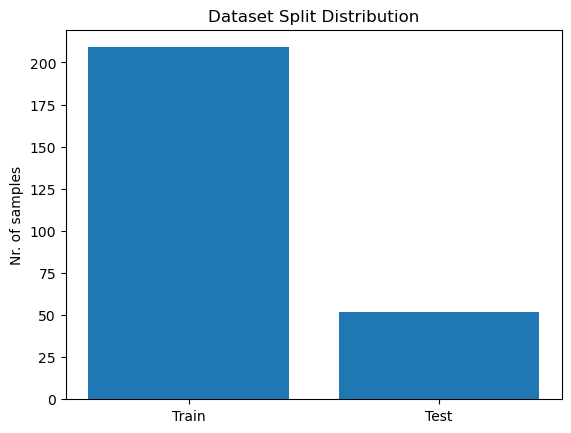

In [240]:
plt.bar(['Train', 'Test'], [len(features_train), len(features_test)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution');

**Exercise**: Split the features tensor into three subsets according to the fractions provided below. One subset is used for training the model, one for validation during training - i.e. to train hyperparameters, and the last subset is used to test the final model. Assign the subsets to variables named `features_train`, `features_val`, and `features_test`, respectively.

In [241]:
train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

In [242]:
features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction])

Text(0.5, 1.0, 'Dataset Split Distribution')

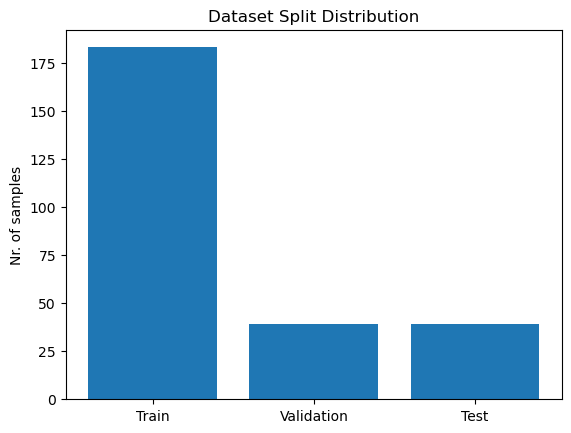

In [243]:
plt.bar(['Train', 'Validation', 'Test'], [len(features_train), len(features_val), len(features_test)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution')

**Exercise**: Set the fraction of the data going into the train dataset to `0.8` and the fractions going into the validation and test subsets to `0.1`. Then, split the features tensor again and run the cell plotting the number of samples in each subdataset.

In [244]:
train_fraction = 0.8
val_fraction = 0.1
test_fraction = 1-train_fraction-val_fraction

features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction])

Text(0.5, 1.0, 'Dataset Split Distribution')

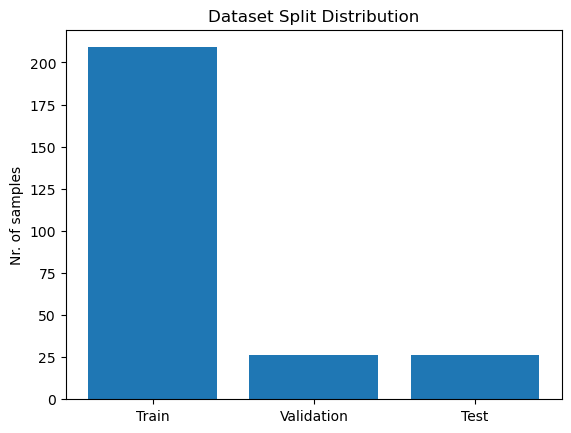

In [245]:
plt.bar(['Train', 'Validation', 'Test'], [len(features_train), len(features_val), len(features_test)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution')

**Exercise**: Split the **labels** tensor into three subsets according to the fractions provided below. One subset is used for training the model, one for validation during training - i.e. to train hyperparameters, and the last subset is used to test the final model. Assign the subsets to variables named `labels_train`, `labels_val`, and `labels_test`, respectively.

In [246]:
train_fraction = 0.8
val_fraction = 0.1
test_fraction = 1-train_fraction-val_fraction

In [247]:
labels_train, labels_val, labels_test = random_split(labels, lengths=[train_fraction, val_fraction, test_fraction])

Text(0.5, 1.0, 'Dataset Split Distribution')

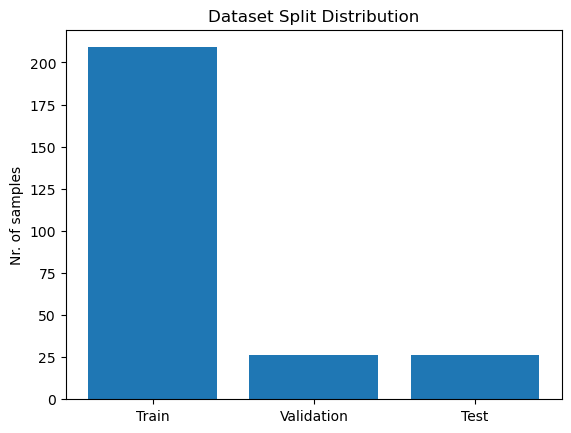

In [248]:
plt.bar(['Train', 'Validation', 'Test'], [len(labels_train), len(labels_val), len(labels_test)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution')

As the name suggests, the `random_split` function splits the data randomly each time it's run. This means that even though the proportions are the same, you'll have different samples in the train, validation, and test subsets each time you run the code to split the data. To ensure reproducibility - that you get the same result each time you train the model on your data, you have to provide a random number generator with a fixed seed to the function.

**Exercise**: In the cell below, the data is split without providing a generator. Run the code in the cell below where features and a label from the training subset is displayed after splitting. Do you get the same or different values when you run the code repeatedly?

In [249]:
train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction])
labels_train, labels_val, labels_test = random_split(labels, lengths=[train_fraction, val_fraction, test_fraction])

features_train[0], labels_train[0]

(tensor([ 0., 19.,  4.,  ...,  1.,  0.,  0.]), tensor(1))

**Exercise**: Create a PyTorch Pseudorandom Number Generator from the seed below.

In [250]:
SEED = 42

In [251]:
SEED = 42
generator = torch.Generator().manual_seed(SEED)
generator

**Exercise**: Create a PyTorch Generator from the seed below. Then, split the run the cell below where the data is split with the generator passed to the `random_split` function. Access the `features` on the first index. Do you get the same or different values for the features when you run the code repeatedly?

In [252]:
SEED = 2026

In [257]:
generator = torch.Generator().manual_seed(SEED)

train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction], generator=generator)
labels_train, labels_val, labels_test = random_split(labels, lengths=[train_fraction, val_fraction, test_fraction], generator=generator)

features_train[0]

tensor([ 0.,  9., 14.,  ...,  0.,  1.,  0.])

## Section 2: Tune Hyperparameters on Validation Dataset

| Code | Description |
| :-- | :-- |
| `for hidden_layer_size in hidden_layer_sizes:` | Loops through each value in the `hidden_layer_sizes` list, assigning it to `hidden_layer_size` |
| `model = Model(hidden_layer_size=hidden_layer_size)` | Creates a new model instance with the specified hidden layer size |
| `utils.train(model, features_train, labels_train)` | Trains the model on the training data. |
| `utils.train(model, features_train, labels_train, learning_rate=learning_rate)` | Trains the model with a specific learning rate |
| `utils.train(model, features_train, labels_train, nepochs=nepochs)` | Trains the model for a specific number of epochs |
| `utils.calculate_accuracy(model, features, labels)` | Calculates the model's accuracy |
| `accuracies_val.append(accuracy_val.item())` | Adds the accuracy value to a list for later comparison |
| `torch.manual_seed(SEED)` | Sets the random seed before creating each model to ensure reproducibility. |

Run the first cell below to split the features and labels into train, validation, and test subsets. Run the second cell to define the model used in this section.

In [258]:
SEED = 2026
generator = torch.Generator().manual_seed(SEED)

train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction], generator=generator)
labels_train, labels_val, labels_test = random_split(labels, lengths=[train_fraction, val_fraction, test_fraction], generator=generator)

features_train, features_val, features_test = features_train.dataset.float(), features_val.dataset.float(), features_test.dataset.float()
labels_train, labels_val, labels_test = labels_train.dataset, labels_val.dataset, labels_test.dataset

In [259]:
n_cells = 1268
n_classes = 3

# define model with two fully connected layers and one ReLU layer between them
class Model(nn.Module):
    def __init__(self, hidden_layer_size = 32):
        super().__init__()

        self.fc1 = nn.Linear(n_cells, hidden_layer_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_layer_size, n_classes)

    def forward(self, x):
        out1 = self.fc1(x)
        out2 = self.relu(out1)
        return self.fc2(out2)


#### **Exercises**

**Example**: Fill the blank lines below to create a list containing the following hidden layer sizes: 8, 32, 128 Then run the code create a new model for each hidden layer size, train the model, and evaluate the trained models accuracy on the validation dataset. Which hidden layer size produces the best result?

100%|██████████| 20/20 [00:00<00:00, 208.58it/s]


(0.0, 101.0)

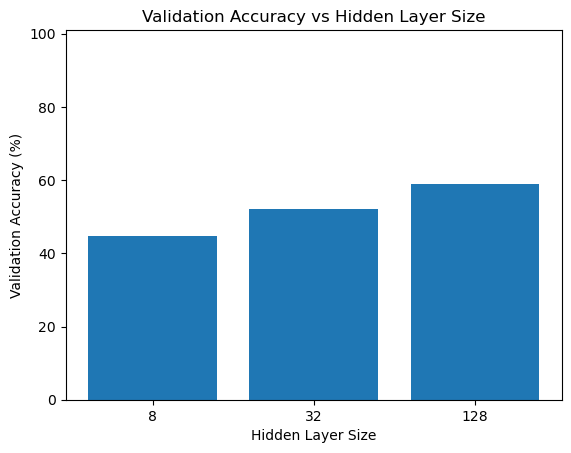

In [260]:
# set hidden layer sizes
hidden_layer_sizes = ___ # complete this line
hidden_layer_sizes = [8, 32, 128] # solution

accuracies_val = []
for hidden_layer_size in hidden_layer_sizes:
    # create model
    torch.manual_seed(SEED)
    model = Model(hidden_layer_size=hidden_layer_size)

    # train the model
    utils.train(model, features_train, labels_train,)

    # Calculate validation accuracy
    accuracy_val = utils.calculate_accuracy(model, features_val, labels_val)
    accuracies_val.append(accuracy_val)

# plot results
plt.bar([str(h) for h in hidden_layer_sizes], accuracies_val)
plt.xlabel('Hidden Layer Size')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy vs Hidden Layer Size')
plt.ylim([0, 101])

The model below is created with `128` neurons in the hidden layer, which produced the best result above.

**Exercise**: Fill the blank line below with a list containing the following learning rates: 0.01, 0.001, 0.0001, 0.00001. Then, run the code create a new model for each learning rate, train the model, and evaluate the trained models accuracy on the validation dataset. Which learning rate produces the best result?

In [261]:
# set learning rates to try out
learning_rates = __ # complete this line

accuracies_val = []
for learning_rate in learning_rates:
    # create model
    torch.manual_seed(SEED)
    model = Model(hidden_layer_size=hidden_layer_size)

    # train the model
    utils.train(model, features_train, labels_train, learning_rate=learning_rate)

    # calculate validation accuracy
    accuracy_val = utils.calculate_accuracy(model, features_val, labels_val)
    accuracies_val.append(accuracy_val)

# plot results
plt.bar([str(lr) for lr in learning_rates], accuracies_val)
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy vs Learning Rate')
plt.ylim([0, 101])

 25%|██▌       | 5/20 [00:00<00:00, 65.99it/s]


KeyboardInterrupt: 

100%|██████████| 20/20 [00:00<00:00, 213.56it/s]


(0.0, 101.0)

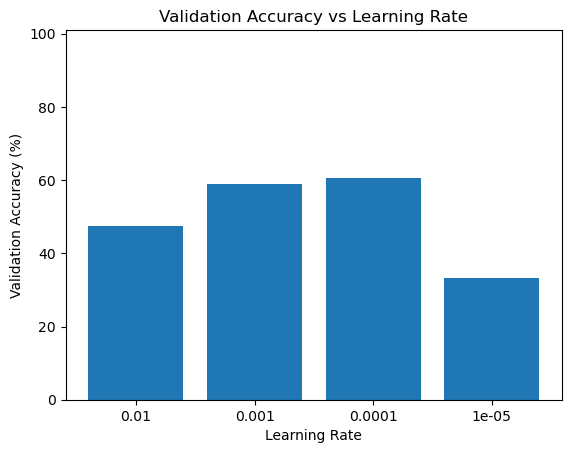

In [262]:
# set learning rates to try out
learning_rates = [0.01, 0.001, 0.0001, 0.00001] # solution

accuracies_val = []
for learning_rate in learning_rates:
    # create model
    torch.manual_seed(SEED)
    model = Model(hidden_layer_size=128)

    # train the model
    utils.train(model, features_train, labels_train, learning_rate = learning_rate,)

    # calculate validation accuracy
    accuracy_val = utils.calculate_accuracy(model, features_val, labels_val)
    accuracies_val.append(accuracy_val)

# plot results
plt.bar([str(lr) for lr in learning_rates], accuracies_val)
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy vs Learning Rate')
plt.ylim([0, 101])

The model below is created with `128` neurons in the hidden layer and the learning rate is set to `0.001`, which are the hyperparameters that produced the best result above.

**Exercise**: Fill the blank line below with a list containing the following number of epochs for which the model will be trained: 20, 100, 200. Then, run the code create a new model for each epoch number, train the model, and evaluate the trained models accuracy on the validation dataset. Which number of epochs produces the best result?

In [ ]:
# set learning rates to try out
number_of_epochs = ___ # complete this line

accuracies_val = []
for nepochs in number_of_epochs:
    # create model
    torch.manual_seed(SEED)
    model = Model(hidden_layer_size=128)

    # train the model
    utils.train(model, features_train, labels_train, learning_rate=0.0001, nepochs=nepochs)

    # calculate validation accuracy
    accuracy_val = utils.calculate_accuracy(model, features_val, labels_val)
    accuracies_val.append(accuracy_val)

# plot results
plt.bar([str(nepochs) for nepochs in number_of_epochs], accuracies_val)
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy vs Number of Epochs')
plt.ylim([0, 101])

100%|██████████| 200/200 [00:01<00:00, 182.36it/s]


(0.0, 101.0)

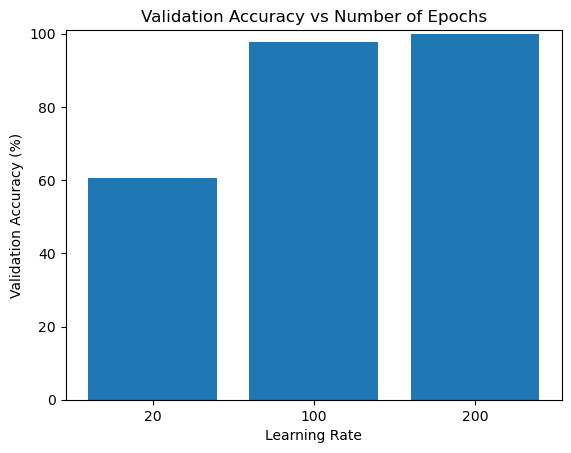

In [263]:
# set learning rates to try out
number_of_epochs = [20, 100, 200] # solution

accuracies_val = []
for nepochs in number_of_epochs:
    # create model
    torch.manual_seed(SEED)
    model = Model(hidden_layer_size=128)

    # train the model
    utils.train(model, features_train, labels_train, learning_rate=0.0001, nepochs=nepochs)

    # calculate validation accuracy
    accuracy_val = utils.calculate_accuracy(model, features_val, labels_val)
    accuracies_val.append(accuracy_val)

# plot results
plt.bar([str(nepochs) for nepochs in number_of_epochs], accuracies_val)
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy vs Number of Epochs')
plt.ylim([0, 101])

**Exercise**: Now that we have found the optimal hyperparameters, we can check how well the model generalizes. That's done by evaluating it on the **test data**, whihc it hasn't seen yet. Fill in the blank lines in the code below to create the final model with the `best_hidden_size`, train it with the `learning_rate = best_learning_rate` and the `nepochs = best_nepochs`, and test it with the `features_test` and `labels_test` subsets.

Does the final model seem to generalize well?

In [264]:
# use best hyperparameters found from tuning
best_hidden_size = 128
best_learning_rate = 0.0001
best_nepochs = 200

# create final model
torch.manual_seed(SEED)
final_model = Model(___) # fill in blank with hidden layer size

utils.train(final_model, features_train, labels_train, __, ___) # fill in blanks with learning rate and number of epochs

# evaluate final model on test data
test_accuracy = utils.calculate_accuracy(final_model, ___, ___) # fill in blanks with the features and labels from the test subset
print(f'\nFinal Test Accuracy: {test_accuracy:.4f}')

TypeError: empty() received an invalid combination of arguments - got (tuple, dtype=NoneType, device=NoneType), but expected one of:
 * (tuple of ints size, *, tuple of names names, torch.memory_format memory_format = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (tuple of ints size, *, torch.memory_format memory_format = None, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


In [266]:
# use best hyperparameters found from tuning
best_hidden_size = 128
best_learning_rate = 0.0001
best_nepochs = 200

# create final model
torch.manual_seed(SEED)
final_model = Model(best_hidden_size) # fill in blank with hidden layer size

utils.train(final_model, features_train, labels_train,nepochs = best_nepochs, learning_rate = best_learning_rate, ) # fill in blanks with learning rate and number of epochs

# evaluate final model on test data
test_accuracy = utils.calculate_accuracy(final_model, features_test, labels_test) # fill in blanks with the features and labels from the test subset
print(f'\nFinal Test Accuracy: {test_accuracy:.1f}')

 12%|█▏        | 24/200 [00:00<00:01, 118.95it/s]

100%|██████████| 200/200 [00:01<00:00, 160.48it/s]


Final Test Accuracy: 100.0


## Section 3: Do Split Sizes Matter?

## Section 4: Batching Data to Train Efficiently

If your dataset is large, you might run out of memory during training. 

| Code | Description |
|---|---|
| `DataLoader(dataset)` | Create a DataLoader for `dataset` and assign it to the variable `dataloader`. |
| `DataLoader(dataset, batch_size = some_num)` | Create a DataLoader for `dataset` where the size of each batch set to `some_num` (default batchsize is 1). |
| `DataLoader(dataset, batch_size = some_num, drop_last = True)` | Create a DataLoader for `dataset` and drop last batch if it's not the same size as the other batches. |
| `DataLoader(dataset, shuffle = True)` | Create a DataLoader for `dataset` and reshuffle the data at each iteration (epoch) during training. |
| `dataloader = DataLoader(dataset)` | Create a DataLoader for `dataset` and assign it to the variable `dataloader`. |

#### **Exercises**

In [4]:
url = 'https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv'
df = pd.read_csv(url)

# the data in the wine column are the labels
labels = df['Wine'].values

# the data from all other columns are the features
features = df.drop(columns='Wine').values

features_orig = torch.tensor(features, dtype=torch.float32)
labels_orig = torch.tensor(labels, dtype=torch.long)
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [5]:
dataset = TensorDataset(features_orig, labels_orig)

**Example**: Create a dataloader using the TensorDataset variable `dataset` created above. Then run the cell below where the dataloader is looped through and the dimensions of the features in each batch are printed. How big is the sample in each batch?

In [6]:
dataloader = DataLoader(dataset)

In [7]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 4:
        break

Batch nr: 0, number of samples in batch: 1, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 1, total number of samples looped through: 1
Batch nr: 2, number of samples in batch: 1, total number of samples looped through: 2
Batch nr: 3, number of samples in batch: 1, total number of samples looped through: 3
Batch nr: 4, number of samples in batch: 1, total number of samples looped through: 4
Batch nr: 5, number of samples in batch: 1, total number of samples looped through: 5


By default, the batch size in the dataloader is `1`.

**Exercise**: Create a dataloader with batch size `8`. Then, run the cell below with the loop going through the batches.

In [8]:
dataloader = DataLoader(dataset, batch_size=8)

In [9]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 5:
        break

Batch nr: 0, number of samples in batch: 8, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 8, total number of samples looped through: 8
Batch nr: 2, number of samples in batch: 8, total number of samples looped through: 16
Batch nr: 3, number of samples in batch: 8, total number of samples looped through: 24
Batch nr: 4, number of samples in batch: 8, total number of samples looped through: 32
Batch nr: 5, number of samples in batch: 8, total number of samples looped through: 40
Batch nr: 6, number of samples in batch: 8, total number of samples looped through: 48


**Exercise**: Create a dataloader with batch size `50` and run the cell with the loop.

In [12]:
dataloader = DataLoader(dataset, batch_size=50)

In [13]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 5:
        break

Batch nr: 0, number of samples in batch: 50, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 50, total number of samples looped through: 50
Batch nr: 2, number of samples in batch: 50, total number of samples looped through: 100
Batch nr: 3, number of samples in batch: 28, total number of samples looped through: 150


The last batch in this dataset has `28` samples when the batch size is set to 50. That's because the total number of samples in the dataset is 178, and 178-150 = 28. There aren't enough samples left to fill up a batch size of 50 in the last iteration.

**Exercise**: Create the dataloader with a batch size of 50 again, but set `drop_last=True`. What happens to the last batch in the loop?

In [14]:
dataloader = DataLoader(dataset, batch_size=50, drop_last=True)

In [15]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 5:
        break

Batch nr: 0, number of samples in batch: 50, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 50, total number of samples looped through: 50
Batch nr: 2, number of samples in batch: 50, total number of samples looped through: 100


If the last batch is smaller than the others, it's dropped when `drop_last` is set to `True`. A useful feature PyTorch's `DataLoader` is that you don't have to add extra code to handle special cases like this yourself when you loop through the batches, the `DataLoader` does it for you. It can also take care of other things like shuffling your data.

**Exercise**: Run the cell below where a dataloader is created with the default batch size and without shuffling. Do you get the same output when you run the cell again?

In [20]:
dataloader = DataLoader(dataset)

feature, label = next(iter(dataloader))
feature, label

(tensor([[1.4230e+01, 1.7100e+00, 2.4300e+00, 1.5600e+01, 1.2700e+02, 2.8000e+00,
          3.0600e+00, 2.8000e-01, 2.2900e+00, 5.6400e+00, 1.0400e+00, 3.9200e+00,
          1.0650e+03]]),
 tensor([1]))

You should get the same feature values and label in the previous exercise no matter how many times you reran the code cell.

**Exercise**: Create a dataloader for the dataset again, but this time, set the parameter `shuffle = True`. Then run the cell below that gets a set of features and their label from the dataset. Do you get the same values when you run it repeatedly now?

In [21]:
dataloader = DataLoader(dataset, shuffle=True)

In [23]:
feature, label = next(iter(dataloader))
feature, label

(tensor([[ 12.2200,   1.2900,   1.9400,  19.0000,  92.0000,   2.3600,   2.0400,
            0.3900,   2.0800,   2.7000,   0.8600,   3.0200, 312.0000]]),
 tensor([2]))